# Helmholtz frequency sweep: pyCAFE vs FEniCSx

**Problem:** 2D rectangular cavity, 1 m × 0.5 m, air (c₀ = 343 m/s, ρ = 1.204 kg/m³).

**BCs:**
- top, bottom, right walls  → hard (Neumann, ∂p/∂n = 0)
- left wall                → imposed normal velocity v_n = 1 m/s (vibrating piston)

**Strong form:** ∇²p + k² p = 0 with k = ω/c₀

**Weak form:**
$$\int_\Omega \nabla p \cdot \nabla v \,d\Omega - \frac{\omega^2}{c_0^2}\int_\Omega p\, v\,d\Omega = i\,\omega\,\rho\,v_n \int_{\Gamma_{\text{left}}} v\,ds$$

We solve frequency-by-frequency on a sweep and compare |p| at a probe point on the right wall.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- Problem parameters ---
Lx   = 1.0
Ly   = 0.5
c0   = 343.0
rho  = 1.204
v_n  = 1.0     # normal velocity on left wall [m/s]

# Frequency sweep
freqs = np.arange(50.0, 800.0 + 1.0, 5.0)
print(f'Sweep: {freqs[0]} → {freqs[-1]} Hz, {len(freqs)} steps')

# Probe: middle of the right wall (rigid)
probe_xy = np.array([Lx, Ly / 2.0])
print(f'Probe point: {probe_xy}')

Sweep: 50.0 → 800.0 Hz, 151 steps
Probe point: [1.   0.25]


---
## 1 — pyCAFE (CQUAD8)

Info    : Reading 'rectangle_CQUAD8.msh'...
Info    : 9 entities
Info    : 6337 nodes
Info    : 2240 elements
Info    : Done reading 'rectangle_CQUAD8.msh'
→ Line 3          | Dim: 1 | Order: 2 | Nodes/Elem: 3 | Count: 192
→ Quadrilateral 8 | Dim: 2 | Order: 2 | Nodes/Elem: 8 | Count: 2048

Available boundary names in the mesh:
-------------------------------------
- bottom               | 127 nodes
- right                | 63 nodes
- top                  | 127 nodes
- left                 | 63 nodes


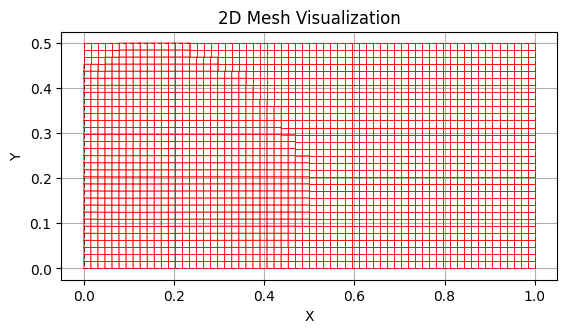

Detected acoustic element type: CQUAD8


pyCAFE  | DOF: 6337  | Sweep time: 6.697 s
Probe node (pyCAFE) idx=138, xy=[1.   0.25]


In [2]:
import pycafe
from pycafe.solver.solver_helmholtz_1 import solve_helmholtz_frequency_sweep

MESH_FILE = 'rectangle_CQUAD8.msh'

fluid = pycafe.load_fluid('air')
nodes, elements, boundaries = pycafe.load_mesh(MESH_FILE)

# BC tuple layout (see prepare_acoustic_system):
# (bc_pressure_zero, bc_pressure_constant, pressure_constant_value,
#  boundary_nodes_impedance, Z_impedance,
#  bc_velocity, value_velocity_normal,
#  source_node, source_pressure_value)
# v_n is the piston velocity toward +x; the BC prescribes the normal
# velocity along the OUTWARD normal of the fluid, which at the left
# wall points toward -x -- hence the minus sign.
bc = ([], [], 0.0, [], 0.0 + 0j, ['left'], -v_n, None, 0.0)

system = pycafe.prepare_acoustic_system(
    nodes=nodes, elements=elements, boundaries=boundaries,
    rho=fluid['rho'], c0=fluid['c0'], bc=bc, debug=False,
)

t0 = time.perf_counter()
P_red = solve_helmholtz_frequency_sweep(
    K_red=system['K_red'],
    M_red=system['M_red'],
    C_red=system['C_red'],
    frequencies=freqs,
    pressure_nodes_red=system['pressure_nodes_red'],
    pressure_values=system['pressure_values'],
    nodes=nodes,
    boundary_velocity_nodes=system['bc_velocity'],
    idx_free=system['idx_free'],
    rho=fluid['rho'],
    v_n=system['value_velocity_normal'],
    boundaries=boundaries,
    elements=elements,
)
t_cafe = time.perf_counter() - t0

# Map reduced solution back to full nodes (no Dirichlet here, idx_free = all)
N_nodes = nodes.shape[0]
P_full = np.zeros((N_nodes, len(freqs)), dtype=complex)
P_full[system['idx_free'], :] = P_red

# Probe: pick the closest mesh node to probe_xy
d2 = (nodes[:, 0] - probe_xy[0])**2 + (nodes[:, 1] - probe_xy[1])**2
probe_node_cafe = int(np.argmin(d2))
print(f'pyCAFE  | DOF: {system["K_red"].shape[0]}  | Sweep time: {t_cafe:.3f} s')
print(f'Probe node (pyCAFE) idx={probe_node_cafe}, xy={nodes[probe_node_cafe, :2]}')

p_probe_cafe = P_full[probe_node_cafe, :]

---
## 2 — FEniCSx (Lagrange Q2)

In [3]:
from mpi4py import MPI
import dolfinx
from dolfinx import mesh as dmesh, fem
from dolfinx.fem import functionspace
from dolfinx.fem.petsc import assemble_matrix as petsc_assemble_matrix
from dolfinx.fem.petsc import assemble_vector as petsc_assemble_vector
import ufl
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# Match pyCAFE element density (rectangle_CQUAD8.msh → ~64x32 Q2)
Nx, Ny = 64, 32

msh = dmesh.create_rectangle(
    MPI.COMM_WORLD,
    [[0.0, 0.0], [Lx, Ly]],
    [Nx, Ny],
    cell_type=dmesh.CellType.quadrilateral,
)

V = functionspace(msh, ('Lagrange', 2))
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# Tag the left boundary (x = 0) for the surface integral
def left_boundary(x):
    return np.isclose(x[0], 0.0)

facet_dim = msh.topology.dim - 1
left_facets = dmesh.locate_entities_boundary(msh, facet_dim, left_boundary)
facet_markers = np.full(left_facets.shape, 1, dtype=np.int32)
sort = np.argsort(left_facets)
facet_tags = dmesh.meshtags(msh, facet_dim, left_facets[sort], facet_markers[sort])
ds = ufl.Measure('ds', domain=msh, subdomain_data=facet_tags)

# Assemble K, M, and the surface load vector once with (real) PETSc,
# then convert to scipy so the frequency loop can run in complex.
a_K = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx
a_M = ufl.inner(u, v) * ufl.dx
L_surf = ufl.inner(fem.Constant(msh, dolfinx.default_scalar_type(1.0)), v) * ds(1)

K_form = fem.form(a_K)
M_form = fem.form(a_M)
L_form = fem.form(L_surf)

K_petsc = petsc_assemble_matrix(K_form); K_petsc.assemble()
M_petsc = petsc_assemble_matrix(M_form); M_petsc.assemble()
b_petsc = petsc_assemble_vector(L_form); b_petsc.assemble()

def petsc_to_scipy(A):
    ai, aj, av = A.getValuesCSR()
    return sp.csr_matrix((av, aj, ai), shape=A.getSize())

K_sp = petsc_to_scipy(K_petsc).astype(complex)
M_sp = petsc_to_scipy(M_petsc).astype(complex)
b_sp = b_petsc.getArray().astype(complex).copy()

n_dof_fenics = V.dofmap.index_map.size_global * V.dofmap.index_map_bs
print(f'FEniCSx | DOF: {n_dof_fenics}')

# Coordinate-based DOF lookup for the probe point
coords_fenics = V.tabulate_dof_coordinates()[:, :2]
d2_f = (coords_fenics[:, 0] - probe_xy[0])**2 + (coords_fenics[:, 1] - probe_xy[1])**2
probe_dof_fenics = int(np.argmin(d2_f))
print(f'Probe DOF (FEniCSx) idx={probe_dof_fenics}, xy={coords_fenics[probe_dof_fenics]}')

# Frequency loop: A = K - (ω/c0)² M, rhs = iωρ v_n * b_surf
p_probe_fenics = np.zeros(len(freqs), dtype=complex)

t0 = time.perf_counter()
for i, f in enumerate(freqs):
    omega = 2 * np.pi * f
    k2 = (omega / c0)**2
    A = (K_sp - k2 * M_sp).tocsc()
    rhs = (1j * omega * rho * v_n) * b_sp
    sol = spla.spsolve(A, rhs)
    p_probe_fenics[i] = sol[probe_dof_fenics]

t_fenics = time.perf_counter() - t0
print(f'FEniCSx sweep time: {t_fenics:.3f} s')

FEniCSx | DOF: 8385
Probe DOF (FEniCSx) idx=7837, xy=[1.   0.25]


FEniCSx sweep time: 7.433 s


---
## 3 — Comparison at the probe point

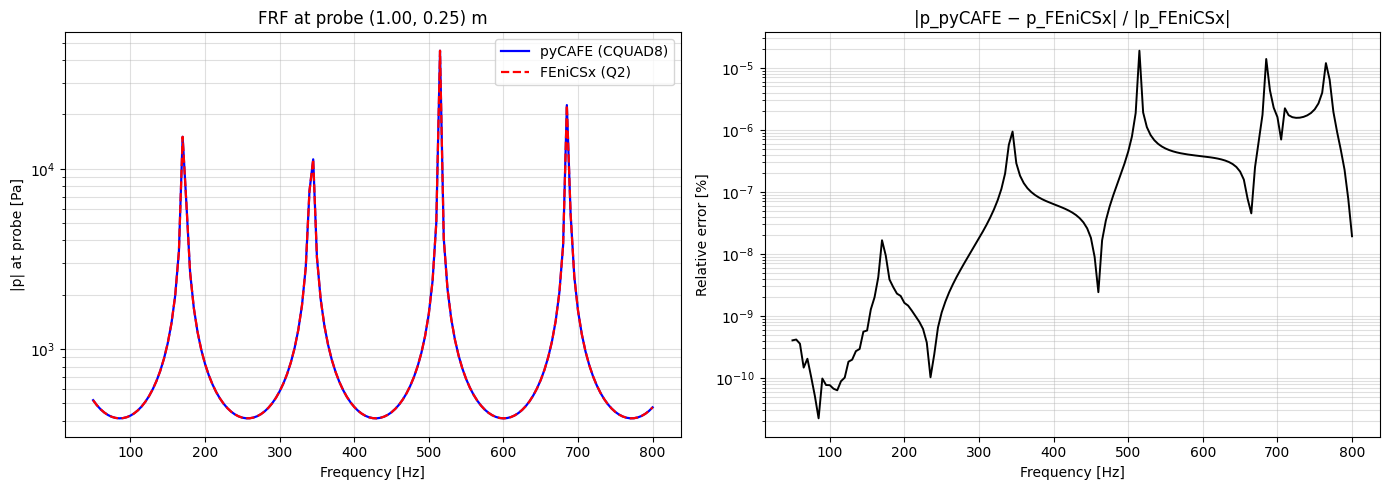

Sweep time → pyCAFE: 6.70 s | FEniCSx: 7.43 s
Median rel. error at probe: 0.000 %
Max    rel. error at probe: 0.000 %


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(freqs, np.abs(p_probe_cafe),   'b-',  lw=1.6, label='pyCAFE (CQUAD8)')
ax.semilogy(freqs, np.abs(p_probe_fenics), 'r--', lw=1.6, label='FEniCSx (Q2)')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('|p| at probe [Pa]')
ax.set_title(f'FRF at probe ({probe_xy[0]:.2f}, {probe_xy[1]:.2f}) m')
ax.grid(True, which='both', alpha=0.4)
ax.legend()

ax2 = axes[1]
denom = np.maximum(np.abs(p_probe_fenics), 1e-12)
rel_err = np.abs(p_probe_cafe - p_probe_fenics) / denom * 100
ax2.semilogy(freqs, rel_err, 'k-', lw=1.4)
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Relative error [%]')
ax2.set_title('|p_pyCAFE − p_FEniCSx| / |p_FEniCSx|')
ax2.grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.savefig('helmholtz_sweep_pycafe_fenics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Sweep time → pyCAFE: {t_cafe:.2f} s | FEniCSx: {t_fenics:.2f} s')
print(f'Median rel. error at probe: {np.median(rel_err):.3f} %')
print(f'Max    rel. error at probe: {np.max(rel_err):.3f} %')